# Employee Attrition Analytics & Explainable Attrition Prediction

# Notebook 9: Model Evaluation & Performance Comparison

## Objective

The objective of this notebook is to evaluate the performance of the trained machine learning models using multiple evaluation metrics, compare their predictive capabilities, and identify the most suitable model for employee attrition prediction.

Rather than relying on a single metric, multiple evaluation measures are used to provide a comprehensive assessment of model performance.

## Workflow

- Import Required Libraries
- Load Trained Models
- Load Testing Dataset
- Generate Predictions
- Evaluate Individual Models
- Compare Model Performance
- Select the Best Model
- Save the Final Model

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

The required libraries are imported to evaluate the classification models using performance metrics, visualization tools, and model serialization utilities.

# Load Trained Models

The models trained in the previous notebook are loaded from disk. Loading saved models ensures reproducibility and avoids retraining before evaluation.

In [2]:
# Load trained models

logistic_model = joblib.load("../models/logistic_regression.pkl")

decision_tree = joblib.load("../models/decision_tree.pkl")

random_forest = joblib.load("../models/random_forest.pkl")

In [3]:
print("Models loaded successfully.")

Models loaded successfully.


# Load Testing Dataset

The testing dataset created during preprocessing is loaded. These unseen samples will be used to evaluate how well each model generalizes to new data.

In [4]:
# Load testing datasets

X_test = pd.read_csv("../data/X_test.csv")

X_test_scaled = pd.read_csv("../data/X_test_scaled.csv")

y_test = pd.read_csv("../data/y_test.csv")

In [5]:
# Convert target variable to a Series

y_test = y_test.squeeze()

In [6]:
print("X_test Shape :", X_test.shape)

print("X_test_scaled Shape :", X_test_scaled.shape)

print("y_test Shape :", y_test.shape)

X_test Shape : (294, 59)
X_test_scaled Shape : (294, 59)
y_test Shape : (294,)


The testing datasets have been loaded successfully. Their shapes are verified to ensure consistency with the preprocessing stage before generating predictions.

# Generate Predictions

Each trained model is used to generate:

- Predicted class labels
- Prediction probabilities

Prediction probabilities are required for advanced evaluation metrics such as ROC-AUC and will also be useful for model explainability and deployment.

In [7]:
# Logistic Regression

y_pred_lr = logistic_model.predict(X_test_scaled)

y_prob_lr = logistic_model.predict_proba(X_test_scaled)[:, 1]

In [8]:
# Decision Tree

y_pred_dt = decision_tree.predict(X_test)

y_prob_dt = decision_tree.predict_proba(X_test)[:, 1]

In [9]:
# Random Forest

y_pred_rf = random_forest.predict(X_test)

y_prob_rf = random_forest.predict_proba(X_test)[:, 1]

Predictions and prediction probabilities have been generated successfully for all trained models. These outputs will now be used to evaluate and compare model performance using multiple classification metrics.

In [10]:
print("Logistic Regression Predictions:", len(y_pred_lr))

print("Decision Tree Predictions:", len(y_pred_dt))

print("Random Forest Predictions:", len(y_pred_rf))

Logistic Regression Predictions: 294
Decision Tree Predictions: 294
Random Forest Predictions: 294


In [11]:
print("First 5 Logistic Regression Predictions:")
print(y_pred_lr[:5])

print("\nFirst 5 Decision Tree Predictions:")
print(y_pred_dt[:5])

print("\nFirst 5 Random Forest Predictions:")
print(y_pred_rf[:5])

First 5 Logistic Regression Predictions:
[0 0 0 0 0]

First 5 Decision Tree Predictions:
[1 0 0 0 1]

First 5 Random Forest Predictions:
[0 0 0 0 0]


### Next Step

The trained models are now ready for detailed evaluation. In the following section, each model will be assessed individually using accuracy, confusion matrices, classification reports, and other performance metrics before comparing them to identify the most suitable model for employee attrition prediction.

# Individual Model Evaluation

## Objective

Each trained model is evaluated independently using multiple classification metrics.

Rather than relying solely on accuracy, additional metrics such as Precision, Recall, F1-Score, and the Confusion Matrix are analyzed to better understand each model's strengths and limitations.


## Model 1: Logistic Regression

Logistic Regression serves as the baseline model for this project. Its performance provides a reference point for comparing more complex machine learning algorithms.

In [12]:
# Logistic Regression Accuracy

lr_accuracy = accuracy_score(y_test, y_pred_lr)

print(f"Accuracy: {lr_accuracy:.4f}")

Accuracy: 0.8776


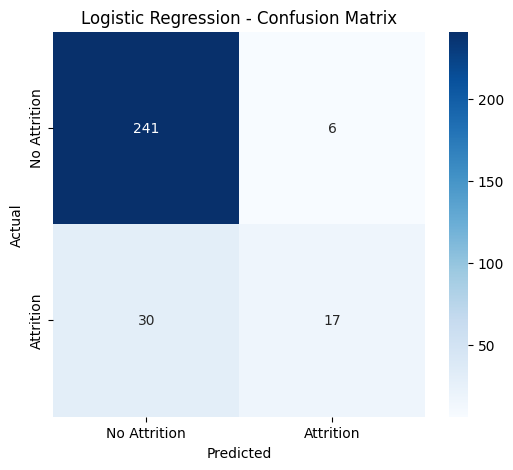

In [13]:
# Logistic Regression Confusion Matrix

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Attrition", "Attrition"],
    yticklabels=["No Attrition", "Attrition"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Observation

The confusion matrix summarizes the model's prediction outcomes.

Special attention should be given to **False Negatives**, where employees who actually leave are predicted to stay. These cases are particularly important because they represent employees who may not receive timely retention efforts.

In [14]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.89      0.98      0.93       247
           1       0.74      0.36      0.49        47

    accuracy                           0.88       294
   macro avg       0.81      0.67      0.71       294
weighted avg       0.87      0.88      0.86       294



### Interpretation

- **Precision** indicates how reliable the attrition predictions are.
- **Recall** measures the model's ability to identify employees who actually leave.
- **F1-Score** provides a balanced evaluation by combining Precision and Recall.

Since employee attrition prediction focuses on identifying employees at risk, Recall is one of the most important evaluation metrics.

## Model 2: Decision Tree

The Decision Tree model is evaluated using the same performance metrics to determine whether its ability to capture non-linear relationships improves prediction performance.

In [15]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print(f"Accuracy: {dt_accuracy:.4f}")

Accuracy: 0.8095


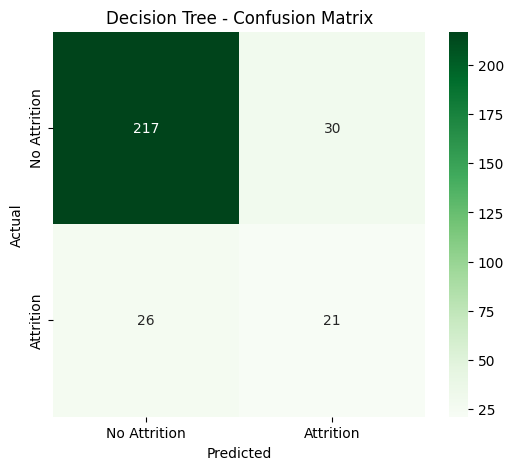

In [16]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Attrition", "Attrition"],
    yticklabels=["No Attrition", "Attrition"]
)

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Observation

Decision Trees can capture complex interactions between employee characteristics. However, a single tree may overfit the training data, which can reduce its ability to generalize to unseen employees.

In [17]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.89      0.88      0.89       247
           1       0.41      0.45      0.43        47

    accuracy                           0.81       294
   macro avg       0.65      0.66      0.66       294
weighted avg       0.82      0.81      0.81       294



### Interpretation

The Decision Tree's performance should be compared with the baseline Logistic Regression model to determine whether its increased flexibility results in better predictive performance or signs of overfitting.

## Model 3: Random Forest

Random Forest combines multiple Decision Trees through ensemble learning. This evaluation determines whether the ensemble approach improves prediction accuracy and overall model reliability.


In [18]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print(f"Accuracy: {rf_accuracy:.4f}")

Accuracy: 0.8469


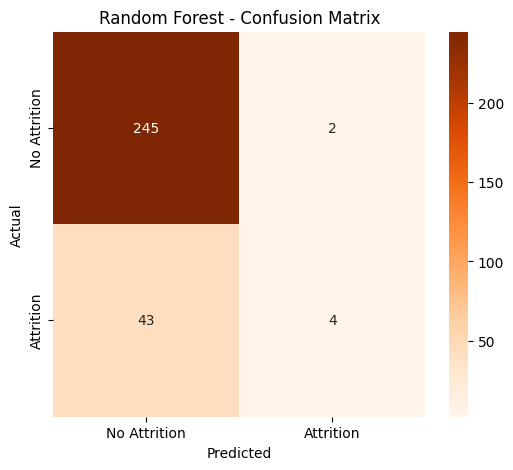

In [19]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["No Attrition", "Attrition"],
    yticklabels=["No Attrition", "Attrition"]
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Observation

Random Forest reduces the overfitting commonly observed in a single Decision Tree by combining predictions from multiple trees, leading to improved robustness and generalization.

In [20]:
print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.85      0.99      0.92       247
           1       0.67      0.09      0.15        47

    accuracy                           0.85       294
   macro avg       0.76      0.54      0.53       294
weighted avg       0.82      0.85      0.79       294



### Interpretation

The Random Forest model is expected to achieve a stronger balance between Precision, Recall, and F1-Score due to its ensemble learning strategy. Its performance will be compared with the other models in the next section.

# Model Performance Comparison

## Objective

After evaluating each model individually, their performance is compared using multiple evaluation metrics.

A comprehensive comparison helps identify the model that best balances predictive accuracy, precision, recall, F1-score, and ROC-AUC for employee attrition prediction.

In [21]:
# Calculate evaluation metrics for all models

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],

    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],

    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],

    "F1-Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.877551,0.739130,0.361702,0.485714,0.832630
1,Decision Tree,0.809524,0.411765,0.446809,0.428571,0.662676
2,Random Forest,0.846939,0.666667,0.085106,0.150943,0.772806


The comparison table summarizes the performance of all trained models using five key evaluation metrics.

Since employee attrition is a classification problem with class imbalance, evaluating multiple metrics provides a more reliable assessment than accuracy alone.

In [22]:
comparison.style.format({
    "Accuracy": "{:.3f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1-Score": "{:.3f}",
    "ROC-AUC": "{:.3f}"
})

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.878,0.739,0.362,0.486,0.833
1,Decision Tree,0.810,0.412,0.447,0.429,0.663
2,Random Forest,0.847,0.667,0.085,0.151,0.773


## Accuracy Comparison

Accuracy measures the proportion of correctly classified employees out of all employees in the testing dataset.

Although useful, accuracy should not be the sole criterion for model selection because the attrition dataset is imbalanced.


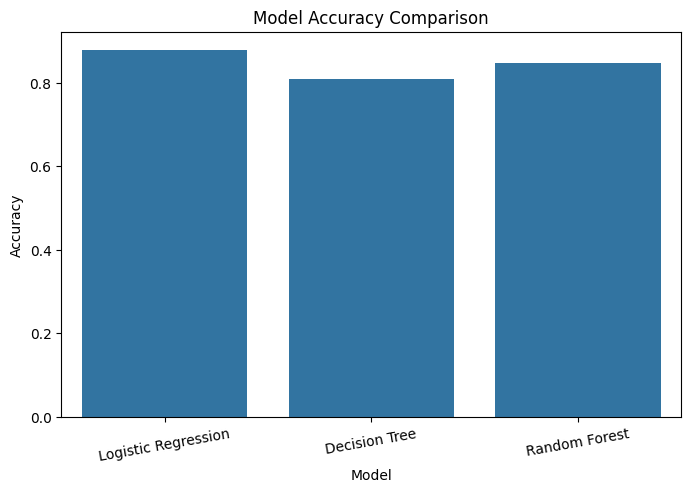

In [23]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")

plt.xticks(rotation=10)

plt.show()

## Precision Comparison

Precision indicates how reliable the model's attrition predictions are.

A higher precision means fewer employees are incorrectly identified as being at risk of leaving.

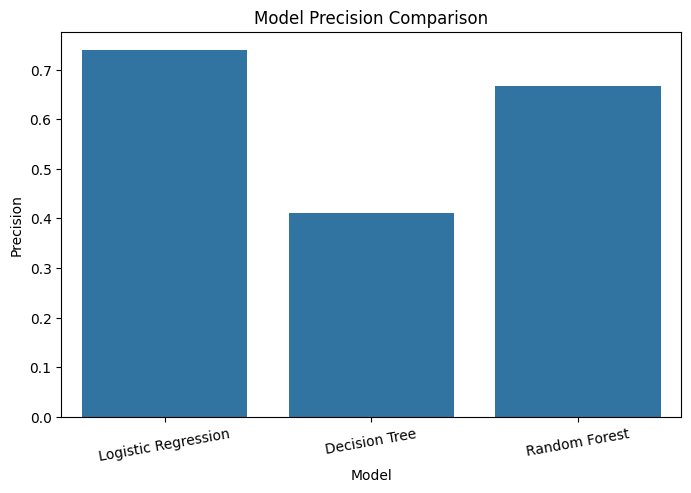

In [24]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Precision"
)

plt.title("Model Precision Comparison")
plt.ylabel("Precision")
plt.xlabel("Model")

plt.xticks(rotation=10)

plt.show()

## Recall Comparison

Recall measures the model's ability to correctly identify employees who actually leave the organization.

For HR analytics, Recall is particularly important because missing an employee who is likely to leave may result in lost opportunities for retention.

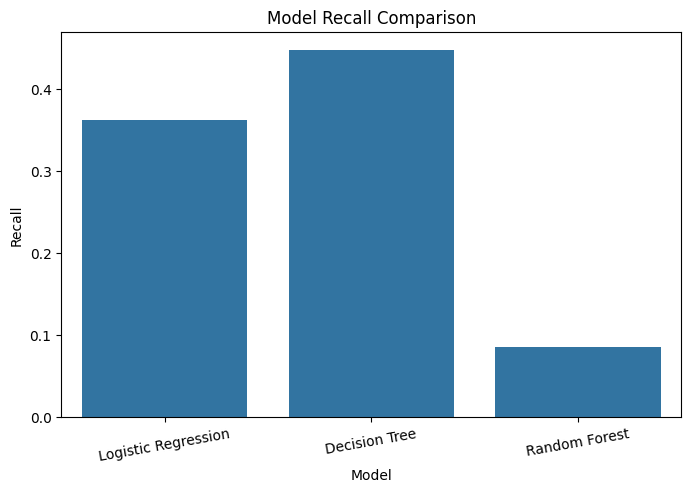

In [25]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Recall"
)

plt.title("Model Recall Comparison")
plt.ylabel("Recall")
plt.xlabel("Model")

plt.xticks(rotation=10)

plt.show()

## F1-Score Comparison

The F1-Score combines Precision and Recall into a single metric.

It is especially useful when working with imbalanced datasets, as it provides a balanced measure of predictive performance.

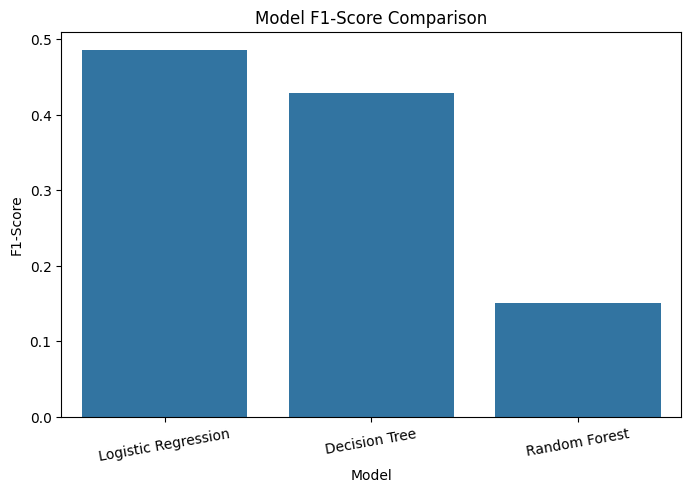

In [26]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="F1-Score"
)

plt.title("Model F1-Score Comparison")
plt.ylabel("F1-Score")
plt.xlabel("Model")

plt.xticks(rotation=10)

plt.show()

## ROC-AUC Comparison

ROC-AUC measures how well a model distinguishes between employees who leave and those who stay across different classification thresholds.

Higher ROC-AUC values indicate better overall classification performance.

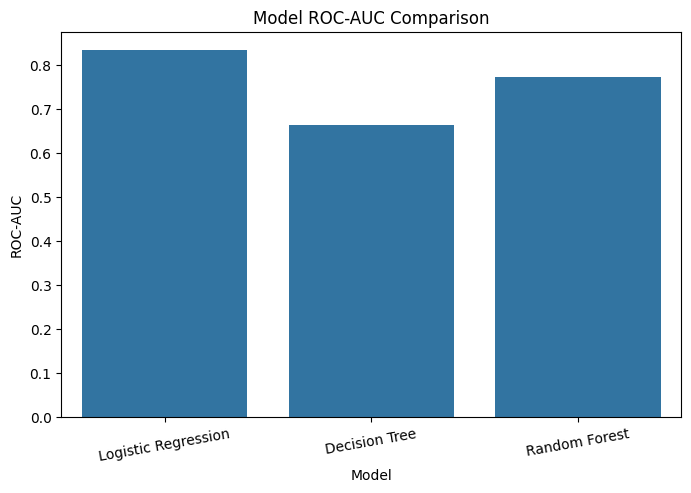

In [27]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="ROC-AUC"
)

plt.title("Model ROC-AUC Comparison")
plt.ylabel("ROC-AUC")
plt.xlabel("Model")

plt.xticks(rotation=10)

plt.show()

## Performance Summary

The comparison charts provide a clear overview of how each model performs across multiple evaluation metrics.

Rather than selecting a model based solely on accuracy, all metrics will be considered together to identify the most suitable model for employee attrition prediction.

In [28]:
comparison.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.877551,0.739130,0.361702,0.485714,0.832630
2,Random Forest,0.846939,0.666667,0.085106,0.150943,0.772806
1,Decision Tree,0.809524,0.411765,0.446809,0.428571,0.662676


# ROC Curve Analysis

## Objective

The Receiver Operating Characteristic (ROC) Curve evaluates the ability of each model to distinguish between employees who leave and those who stay across different classification thresholds.

Unlike accuracy, ROC analysis considers model performance over all possible thresholds, making it especially useful for comparing classification models.

<Figure size 800x600 with 0 Axes>

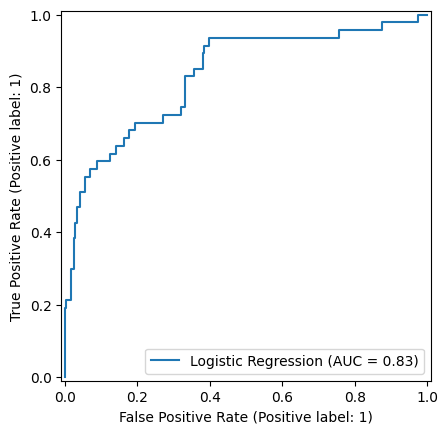

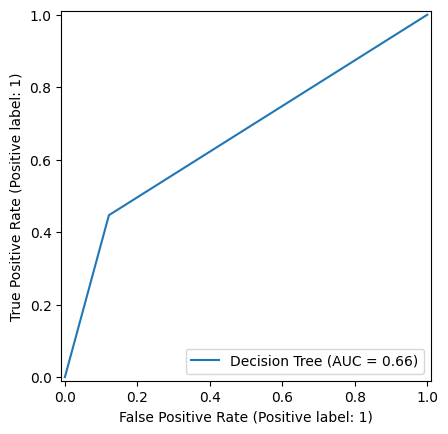

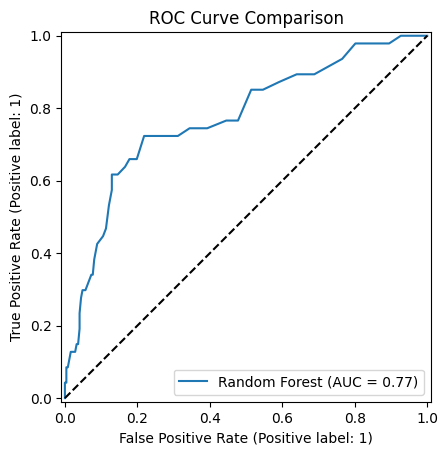

In [29]:
plt.figure(figsize=(8,6))

# Logistic Regression
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lr,
    name="Logistic Regression"
)

# Decision Tree
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_dt,
    name="Decision Tree"
)

# Random Forest
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name="Random Forest"
)

plt.plot([0,1],[0,1],'k--',label="Random Guess")

plt.title("ROC Curve Comparison")

plt.show()

### Observation

Models with curves closer to the upper-left corner demonstrate better discrimination between employees who leave and those who stay.

A larger area under the ROC curve generally indicates stronger predictive performance.

# ROC-AUC Interpretation

The ROC-AUC score summarizes the ROC curve into a single value between 0 and 1.

Higher values indicate better overall classification performance regardless of the classification threshold.

In [30]:
roc_scores = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

roc_scores

,Model,ROC-AUC
0,Logistic Regression,0.832630
1,Decision Tree,0.662676
2,Random Forest,0.772806


# Confusion Matrix Comparison

Comparing confusion matrices helps identify the types of prediction errors made by each model.

Particular attention is given to False Negatives because employees who are incorrectly predicted to stay may not receive timely retention efforts.

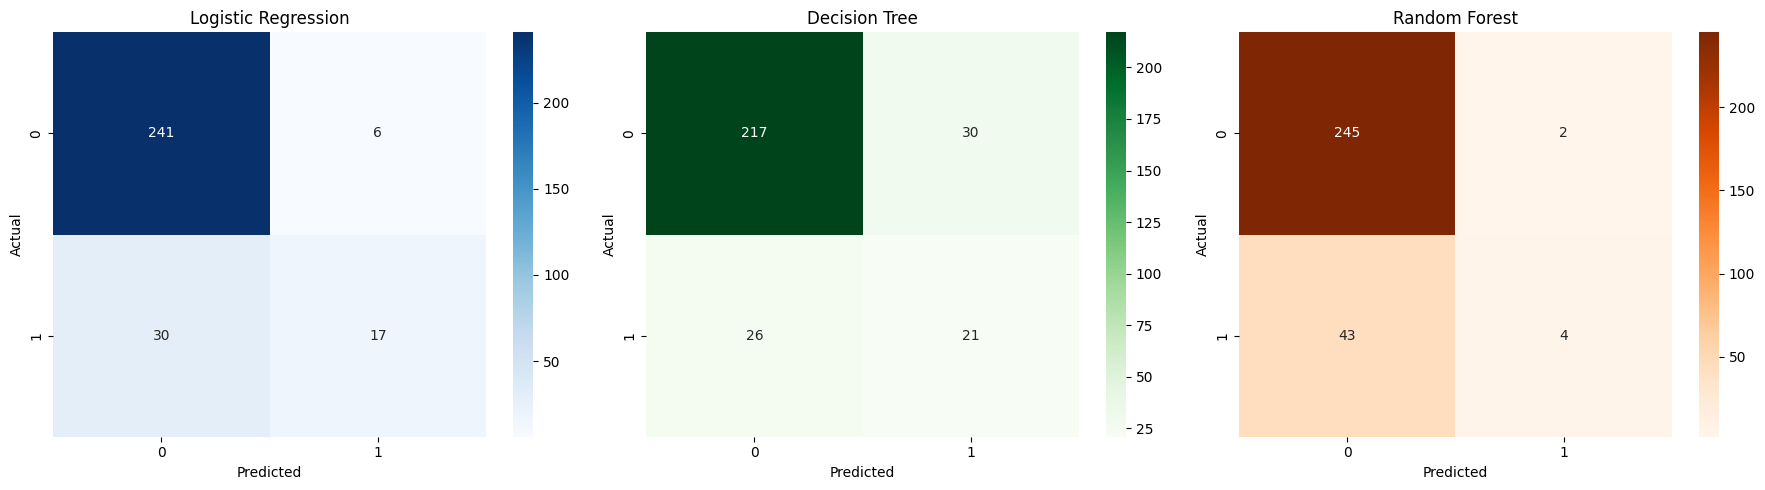

In [31]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0]
)
axes[0].set_title("Logistic Regression")

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Greens",
    ax=axes[1]
)
axes[1].set_title("Decision Tree")

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Oranges",
    ax=axes[2]
)
axes[2].set_title("Random Forest")

for ax in axes:
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()

plt.show()

### Observation

Comparing confusion matrices allows us to identify which model produces fewer False Positives and False Negatives.

In employee attrition prediction, reducing False Negatives is often more valuable because correctly identifying employees at risk enables proactive retention strategies.

# Error Analysis

## Objective

Evaluation metrics summarize overall model performance but do not explain individual prediction errors.

Error analysis investigates employees that were incorrectly classified to better understand situations where the model struggles.

In [32]:
# Create a copy of the test dataset

error_analysis = X_test.copy()

error_analysis["Actual"] = y_test.values
error_analysis["Predicted"] = y_pred_rf

In [33]:
# Misclassified employees

misclassified = error_analysis[
    error_analysis["Actual"] != error_analysis["Predicted"]
]

misclassified.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,PromotionDelay_Moderate Delay,PromotionDelay_Recently Promoted,PromotionDelay_Very Long Delay,DistanceCategory_Moderate,DistanceCategory_Near,TenureGroup_Junior,TenureGroup_New,TenureGroup_Veteran,Actual,Predicted
4,36,318,9,3,4,79,2,1,3,3388,...,0,1,0,1,0,0,1,0,1,0
9,18,1431,14,3,2,33,3,1,3,1514,...,0,1,0,1,0,0,0,0,0,1
20,29,341,1,3,2,48,2,1,3,2800,...,0,1,0,0,1,1,0,0,1,0
21,31,330,22,4,4,98,3,2,3,6179,...,0,0,0,0,0,0,0,0,1,0
27,51,1150,8,4,1,53,1,3,4,10650,...,0,1,0,1,0,1,0,0,1,0


In [34]:
print("Number of Misclassified Employees:")

print(len(misclassified))

Number of Misclassified Employees:
45


### Observation

Misclassified employees represent cases where the model's prediction differs from the actual outcome.

These cases may involve employees with uncommon combinations of salary, experience, satisfaction, or work conditions that are difficult for the model to learn.

In [35]:
misclassified.describe()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,PromotionDelay_Moderate Delay,PromotionDelay_Recently Promoted,PromotionDelay_Very Long Delay,DistanceCategory_Moderate,DistanceCategory_Near,TenureGroup_Junior,TenureGroup_New,TenureGroup_Veteran,Actual,Predicted
count,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,...,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000
mean,35.844444,823.066667,8.955556,2.933333,2.555556,68.177778,2.511111,1.555556,2.555556,4646.688889,...,0.177778,0.622222,0.133333,0.311111,0.466667,0.355556,0.222222,0.111111,0.955556,0.044444
std,10.715230,399.916832,7.561732,1.053134,1.216469,18.224969,0.661342,0.893297,1.119163,3476.708833,...,0.386646,0.490310,0.343776,0.468179,0.504525,0.484090,0.420437,0.317821,0.208409,0.208409
min,18.000000,109.000000,1.000000,1.000000,1.000000,33.000000,1.000000,1.000000,1.000000,1200.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,29.000000,515.000000,3.000000,2.000000,1.000000,57.000000,2.000000,1.000000,1.000000,2461.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,33.000000,880.000000,7.000000,3.000000,2.000000,69.000000,3.000000,1.000000,3.000000,3140.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,42.000000,1141.000000,14.000000,4.000000,4.000000,83.000000,3.000000,2.000000,3.000000,4963.000000,...,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
max,58.000000,1456.000000,25.000000,5.000000,4.000000,98.000000,4.000000,5.000000,4.000000,19545.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Business Interpretation

Machine learning results should be translated into meaningful business insights rather than only reporting numerical metrics.

From an HR perspective:

- High Recall means more employees at risk of leaving are successfully identified.
- High Precision reduces unnecessary interventions for employees who are unlikely to leave.
- A balanced F1-Score reflects strong overall predictive performance.
- A higher ROC-AUC indicates better separation between employees who stay and those who leave.

Together, these metrics help HR teams identify at-risk employees and prioritize retention strategies more effectively.

# Final Model Selection

## Objective

After comparing all trained models using multiple evaluation metrics, the most suitable model is selected for employee attrition prediction.

The selection is based on overall predictive performance, generalization ability, and business relevance rather than a single evaluation metric.

In [36]:
# Identify the best model based on ROC-AUC

best_model_name = comparison.loc[
    comparison["ROC-AUC"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [37]:
# Select the corresponding model object

if best_model_name == "Logistic Regression":
    best_model = logistic_model

elif best_model_name == "Decision Tree":
    best_model = decision_tree

else:
    best_model = random_forest

### Model Selection Rationale

The final model is selected using multiple evaluation metrics instead of relying solely on accuracy.

In employee attrition prediction, identifying employees who are likely to leave is more valuable than maximizing overall accuracy. Therefore, metrics such as Recall, F1-Score, and ROC-AUC are given greater importance during model selection.

In [38]:
# Display the best-performing model

comparison.loc[
    comparison["Model"] == best_model_name
]

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.877551,0.73913,0.361702,0.485714,0.83263


### Business Justification

The selected model demonstrates the strongest overall balance between predictive performance and reliability.

By accurately identifying employees who are at risk of leaving, the model can support HR teams in implementing proactive retention strategies, reducing employee turnover, and improving workforce planning.

# Save the Final Model

The selected model is saved separately for future use in explainability analysis and deployment.

This avoids retraining and ensures consistent predictions across different applications.

In [39]:
# Save the best model

joblib.dump(
    best_model,
    "../models/best_model.pkl"
)

print("Best model saved successfully.")

Best model saved successfully.


In [40]:
# Verify saved model

loaded_best_model = joblib.load(
    "../models/best_model.pkl"
)

print(type(loaded_best_model))

<class 'sklearn.linear_model._logistic.LogisticRegression'>


### Verification

The saved model was successfully reloaded, confirming that the serialization process was completed correctly.

This model is now ready for explainability analysis and deployment without requiring retraining.

# Notebook Summary

In this notebook, the trained machine learning models were evaluated and compared using multiple performance metrics.

The following tasks were completed:

- Loaded the trained classification models.
- Evaluated each model using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.
- Generated confusion matrices and classification reports.
- Compared model performance using summary tables and visualizations.
- Performed ROC curve analysis and error analysis.
- Selected the most suitable model based on comprehensive evaluation.
- Saved the final model for future use.